Notebook made by Juan David Sánchez. Contact us: juan.sanchez34@udea.edu.co

# **Sesión 4 - Análisis y visualización de información química**

📗📘📙📌 **Se seleccionó el target Proteína precursora amiloidea (Amyloid precursor protein) APP para este trabajo** 

**Se obtuvieron las bioactividades reportadas para el target APP en Pubchem (Dataset 1) y en ChEMBL (Dataset2). Luego se realizó una limpieza a cada dataset, se calcularon algunos descriptores químicos y finalmente se concatenaron para realizar un análisis final de los datos** 📌📙📘📗

# Target: Amyloid-beta precursor protein

Although clinical trials targeting Aβ have yielded disappointing results, its central role in plaque formation and disease pathology makes it a biologically validated and structurally well-studied target. Virtual screening provides an opportunity to identify novel small molecules that may interfere with fundamental pathways in ways not previously explored.


* Zhang, Y., Chen, H., Li, R. et al. Amyloid β-based therapy for Alzheimer’s disease: challenges, successes and future. Sig Transduct Target Ther 8, 248 (2023). https://doi.org/10.1038/s41392-023-01484-7

* Karahan H, Hartigan K, Al-Amin MM, et al. Deletion of neuronal Idol ameliorates Alzheimer's disease–related pathologies via APOE receptors. Alzheimer's Dement. 2025; 21:e70949. https://doi.org/10.1002/alz.70949


Amyloid-beta precursor protein (APP) / P05067 · A4_HUMAN

* https://www.uniprot.org/uniprotkb/P05067/entry



📗📘📙📌 **Importe de librerías necesarias para el proyecto** 📌📙📘📗

In [37]:
# Importing necessary libraries

import os
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib.request

import pip
! pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem import RDConfig
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
PandasTools.RenderImagesInAllDataFrames(images=True)

! pip install chembl_webresource_client
from chembl_webresource_client.new_client import new_client as search
from chembl_webresource_client.utils import utils

📗📘📙📌 **Formato básico para usar la API de Pubchem** 📌📙📘📗

**The URL Path - Pubchem**

Most – if not all – of the information the service needs to produce its results is encoded into the URL. The general form of the URL has three parts – input, operation, and output – after the common prefix, followed by operation options as URL arguments (after the ‘?’):

In [38]:
# https://pubchem.ncbi.nlm.nih.gov/rest/pug/<input specification>/<operation specification>/[<output specification>][?<operation_options>]

**Bioactivities from Protein - Pubchem**

This operation returns the concise bioactivity data for a given protein. Valid output formats are XML, JSON(P), ASNT/B, and CSV.

https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/Q01279/concise/JSON

For some proteins with a large amount of data, the operation may time out. In such cases, one can first get the list of AIDs tested against the given protein, e.g.:

https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/Q01279/aids/TXT

Then aggregate the concise bioactivity data from each AID:

https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/66438/concise/JSON

📗📘📙📌 **Estructura de URL para obtener bioactividades a partir de proteínas en Pubchem** 📌📙📘📗

In [39]:
# Bioactivities from Protein

# URL = prolog + / + input + / + operation + / + output + options

# Uniprot ID of the target protein: P05067

target = 'P05067'

prolog = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'


# 🟢 Input
# <domain> = substance | compound | assay | gene | protein | pathway | taxonomy | cell | <other inputs>
# protein domain <namespace> = accession | gi | synonym
input = f'protein/accession/{target}'

# 🟡 Operation
# protein domain <operation specification> = summary | aids | concise | pwaccs
operation = 'concise'

# 🔵 output
# <output specification> = XML | ASNT | ASNB | JSON | JSONP [ ?callback=<callback name> ] | SDF | CSV | PNG | TXT
output = 'CSV'

# 🔴 Options
options = '' # '' Si no se requiere nada en esoecific

# URL construction
url = f'{prolog}/{input}/{operation}/{output}{options}'
print(f'🔗 La URL de búsqueda en Pubchem es: {url}')

🔗 La URL de búsqueda en Pubchem es: https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/P05067/concise/CSV


📗📘📙📌 **Creación del dataset a partir de los datos obtenidos a través del API de PubChem** 📌📙📘📗

In [40]:
# Creation of a dataset from search results
app_df_pubchem = pd.read_csv(url, low_memory=False)
print(f'📊 El número de compuestos con información de bioactividad para la proteína APP es: {len(app_df_pubchem)}\n')

# Save the initial size of the dataset
initial_size_pubchem = len(app_df_pubchem)
app_df_pubchem.info()

📊 El número de compuestos con información de bioactividad para la proteína APP es: 418493

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418493 entries, 0 to 418492
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   AID                  418493 non-null  int64  
 1   SID                  418493 non-null  int64  
 2   CID                  418444 non-null  float64
 3   Activity Outcome     418493 non-null  object 
 4   Target GeneID        418154 non-null  float64
 5   Activity Name        4410 non-null    object 
 6   Activity Qualifier   2158 non-null    object 
 7   Activity Value [uM]  2920 non-null    float64
 8   Assay Name           418493 non-null  object 
 9   Assay Type           418493 non-null  object 
 10  PubMed ID            8825 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 35.1+ MB


📗📘📙📌 **Vizualización y limpieza inicial del dataframe** 📌📙📘📗

In [41]:
# Preserving only molecules that contain activity data (IC50, Ki, EC50, etc.)
app_df_pubchem = app_df_pubchem[app_df_pubchem['Activity Value [uM]'].notna()]
print(f'🔶 El número de compuestos con datos de bioactividad para la proteína APP es: {len(app_df_pubchem)}\n')
app_df_pubchem['Activity Name'].value_counts()

🔶 El número de compuestos con datos de bioactividad para la proteína APP es: 2920



Activity Name
IC50        1913
Ki           576
EC50         214
Kd           133
Potency       66
DC50          11
Bmax           3
Activity       3
INH            1
Name: count, dtype: int64

In [42]:
# Presenving only molecules with IC50 values
app_df_pubchem = app_df_pubchem[app_df_pubchem['Activity Name'] == 'IC50']
print(f'🔷 El número de compuestos con datos de IC50 para la proteína APP es: {len(app_df_pubchem)}\n')

# Dropping rows with missing CID values and duplicates
app_df_pubchem = app_df_pubchem.dropna(subset=['CID'])
app_df_pubchem = app_df_pubchem.drop_duplicates(subset=['CID'])
print(f'🔶 El número de compuestos únicos con CID válido es: {len(app_df_pubchem)}')

# Converting the CID column to string type for better handling
app_df_pubchem['CID'] = app_df_pubchem['CID'].astype(int)
app_df_pubchem['CID'] = app_df_pubchem['CID'].astype('string')

# Extracting unique CIDs for better retrival of SMILES
unique_cids = app_df_pubchem['CID'].dropna().unique().astype(str)

🔷 El número de compuestos con datos de IC50 para la proteína APP es: 1913

🔶 El número de compuestos únicos con CID válido es: 1475


📗📘📙📌 **Formato necesario para la busqueda de SMILES (a partir de cid) en PUG-REST** 📌📙📘📗

In [43]:
# Retrieving SMILES from cids in Pubchem
cids = 'cids.text'
prolog = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'
input = f'compound/cid/{cids}'
operation = 'property/SMILES'
output = 'TXT'
options = ''

# URL construction
url = f'{prolog}/{input}/{operation}/{output}{options}'

📗📘📙📌 **Función para generar una búsqueda estructurada por bloques en PUG-REST y mapeo al dataframe** 📌📙📘📗

In [44]:
# Fuction to get smiles in batch
def get_smiles_batch(cid_batch):
    cids_str = ",".join(cid_batch)
    url = f'{prolog}/compound/cid/{cids_str}/{operation}/{output}{options}'
    response = requests.get(url)
    if response.status_code == 200:
        smiles_list = response.text.strip().split("\n")
        return dict(zip(cid_batch, smiles_list))
    else:
        return {}

# Request with a batch of CIDs
batch_size = 100  # In order not to overload API
cid_smiles_dict = {}

for i in range(0, len(unique_cids), batch_size):
    batch = unique_cids[i:i+batch_size]
    cid_smiles_dict.update(get_smiles_batch(batch))

# Mapping the SMILES to the dataframe
app_df_pubchem['SMILES'] = app_df_pubchem['CID'].astype(str).map(cid_smiles_dict)
app_df_pubchem.sample(5)

,AID,SID,CID,Activity Outcome,Target GeneID,Activity Name,Activity Qualifier,Activity Value [uM],Assay Name,Assay Type,PubMed ID,SMILES
5046,1193164,312383604,71288593,Active,351.0,IC50,=,0.110,Inhibition of production of human amyloidbeta4...,Confirmatory,25708617.0,CCO[C@@H]([C@H]1C[C@H]([C@H]2[C@H](O1)[C@@H]([...
383732,1983228,504816721,92269016,Active,351.0,IC50,=,4.300,Inhibition of amyloid beta 40 peptide (unknown...,Confirmatory,36753881.0,CC1=C2C(=C(C=C1)NC[C@@H]3CCCN4[C@@H]3CCCC4)C(=...
7842,1323641,374320186,22361008,Active,351.0,IC50,=,4.600,Inhibition of amyloid beta (1 to 42 residues) ...,Confirmatory,27624076.0,COC1=C(C=CC(=C1)O)/C=C/C(=O)CC(=O)/C=C/C2=C(C=...
377811,1751085,469825098,164627187,Active,351.0,IC50,=,2.160,Inhibition of self-induced amyloid beta(1 to 4...,Confirmatory,34153471.0,C1CC2=NC3=C(C=C(C=C3)NC(=O)C4=CC5=CC=CC=C5N4)C...
7194,1156052,242645763,73296810,Active,351.0,IC50,=,0.018,Inhibition of amyloid beta (unknown origin) ag...,Confirmatory,24944730.0,COC1=CC(=CC(=C1O)O)/C=C\2/C(=O)N3C=C(N=C3S2)C4...


📗📘📙📌 **Eliminación de algunas columnas y limpieza adicional del dataframe** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules
4549,73294880,IC50,10000.0,COC1=C(C(=CC(=C1)/C=C\2/C(=O)N3C=C(N=C3S2)C4=C...,
383204,67979436,IC50,5870.0,CC1=N[C@@]2(C3=C(CC24CCC(CC4)OC)C=CC(=C3)C5=CC...,
7808,122179368,IC50,10100.0,C[C@]12[C@H](C[C@@H](C3=COC(=C31)C(=O)C4=C2C=C...,
417279,58512317,IC50,23800.0,C1=CC(=NC2=C1C=CN2)NC3=CC4=C(C=CN4)N=C3,
5906,71764832,IC50,14160.0,CN(C)C1=CC=CC=C1CNC2=CC=C(C=C2)/C=C/C3=CC(=CC(...,

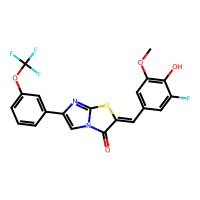
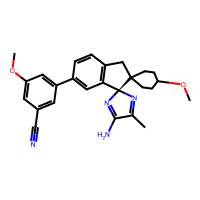
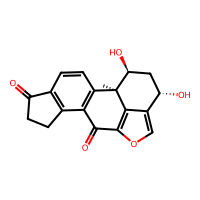
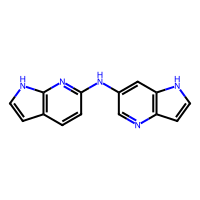
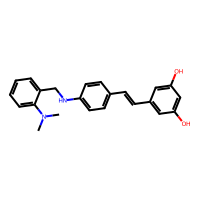

In [45]:
# Removing unnecessary columns
columns_to_remove = ['AID', 'SID', 'Activity Qualifier', 'Activity Outcome', 'Assay Name', 'Target GeneID', 'Assay Type', 'PubMed ID']
app_df_pubchem = app_df_pubchem.drop(columns=columns_to_remove)

# Converting the activity values to nm scale (1 nM = 1000 uM)
app_df_pubchem['Activity Value [uM]'] = app_df_pubchem['Activity Value [uM]'].apply(lambda x: x * 1000)
app_df_pubchem.rename(columns={'Activity Value [uM]': 'Activity Value [nM]'}, inplace=True)

# Renaming the ID column
app_df_pubchem.rename(columns={'CID': 'Pubchem_id'}, inplace=True)
app_df_pubchem.sample(5)

# Removing rows with missing SMILES values
app_df_pubchem = app_df_pubchem.dropna(subset=['SMILES'])


# Adding a column with the 2d structures of the molecules
app_df_pubchem['Molecules'] = app_df_pubchem['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))

# Save the final size of the dataset
final_size_pubchem = len(app_df_pubchem)

app_df_pubchem.sample(5)

📗📘📙📌 **Reporte del proceso de curado del dataset 1** 📌📙📘📗

In [46]:
# Report
print('🧪 Origen de la base de datos: Pubchem\n')
print(f'🔷 Número de compuestos antes del curado: {initial_size_pubchem}\n')
print(f'🔶 Número de compuestos después del curado: {final_size_pubchem}')

🧪 Origen de la base de datos: Pubchem

🔷 Número de compuestos antes del curado: 418493

🔶 Número de compuestos después del curado: 1475


📗📘📙📌 **Cálculo de descriptores** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
418106,166625322,IC50,30.0,C[C@]1(CO[C@@](C(=N1)N)(C)C(F)(F)F)C2=C(C=CC(=...,,494.130121,7,3,3.3926,128.51,0.368421,3,15,3
382251,6506968,IC50,5700.0,C1=CC(=C(C=C1C[C@@H](C(=O)O)NC(=O)/C=C/C2=CC(=...,,359.100502,6,6,1.3343,147.32,0.111111,2,8,6

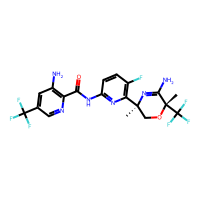
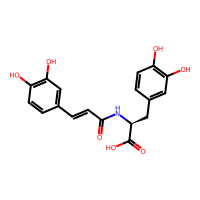

In [47]:
# Calculation of descriptors of interest for the analysis
app_df_pubchem["MW"] = app_df_pubchem["Molecules"].apply(Descriptors.ExactMolWt)
app_df_pubchem["HBA"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHAcceptors)
app_df_pubchem["HBD"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHDonors)
app_df_pubchem["logP"] = app_df_pubchem["Molecules"].apply(Descriptors.MolLogP)
app_df_pubchem["TPSA"] = app_df_pubchem["Molecules"].apply(Descriptors.TPSA)
app_df_pubchem["CSP3"] = app_df_pubchem["Molecules"].apply(Descriptors.FractionCSP3)
app_df_pubchem["NumRings"] = app_df_pubchem["Molecules"].apply(Descriptors.RingCount)
app_df_pubchem["HetAtoms"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHeteroatoms)
app_df_pubchem["RotBonds"] = app_df_pubchem["Molecules"].apply(Descriptors.NumRotatableBonds)

app_df_pubchem.sample(2)

📗📘📙📌 **Filtrado y normalización de los datos** 📌📙📘📗

In [48]:
# Creation of a new dataset with only the descriptors
descriptors_df_pubchem = app_df_pubchem[['MW', 'HBA', 'HBD', 'logP', 'TPSA', 'CSP3', 'NumRings', 'HetAtoms', 'RotBonds']]
descriptors_df_pubchem.sample(5)

,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
418407,463.249587,8,1,4.14652,80.99,0.520000,6,9,5
378343,424.066236,7,2,2.58848,126.28,0.235294,3,12,3
417553,580.136947,10,3,6.04300,148.80,0.090909,6,10,6
6860,491.242021,5,1,3.20780,88.18,0.607143,8,8,0
479,516.126776,11,7,1.02960,211.28,0.240000,3,12,7


In [49]:
from sklearn.preprocessing import StandardScaler

# z-score: media = 0 std = 1 - z = x-mean/std
scale = StandardScaler(with_mean=True, with_std=True)

# Scaling the descriptor data
scaled_descriptors_pubchem = scale.fit_transform(descriptors_df_pubchem)

# Creating a new dataframe with the scaled descriptors
scaled_descriptors_df_pubchem = pd.DataFrame(scaled_descriptors_pubchem, columns=descriptors_df_pubchem.columns)

# Verification of the scaled data
scaled_descriptors_df_pubchem.describe()

,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
count,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03
mean,4.094653e-16,-5.780687e-17,-6.744134e-17,-2.914430e-16,-2.023240e-16,-2.890343e-17,-1.156137e-16,3.853791e-17,5.539825e-17
std,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00
min,-2.462792e+00,-2.620673e+00,-1.256547e+00,-4.996290e+00,-2.291299e+00,-1.527012e+00,-2.715355e+00,-2.397338e+00,-1.379330e+00
25%,-6.775237e-01,-7.202342e-01,-5.285790e-01,-6.437349e-01,-6.059324e-01,-8.271295e-01,-6.437263e-01,-7.448128e-01,-6.262721e-01
50%,-7.373875e-02,-2.451244e-01,-5.285790e-01,-4.269690e-02,-1.486885e-01,-5.725907e-02,4.681646e-02,-4.143077e-01,-1.242333e-01
75%,5.292265e-01,7.050951e-01,1.993893e-01,5.868609e-01,3.240124e-01,6.503996e-01,7.373592e-01,5.772075e-01,3.778054e-01
max,9.060500e+00,6.881522e+00,7.479073e+00,5.492461e+00,1.012623e+01,3.372164e+00,3.499530e+00,8.178825e+00,6.904309e+00


📗📘📙📌 **Matriz y análisis de correlación** 📌📙📘📗

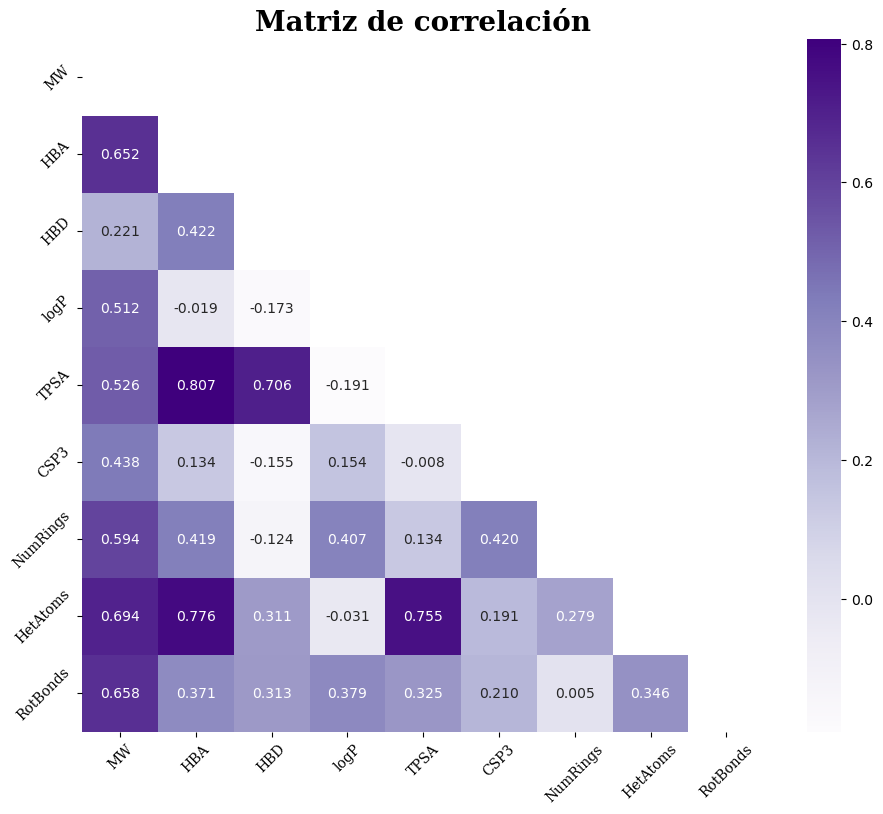

In [50]:
# Correlation matrix of the descriptors
plt.figure(figsize=(11,9))
corr_df = scaled_descriptors_df_pubchem.corr() # To remove the upper triangle of the matrix (we can use a mask)
sns.heatmap(corr_df, annot=True, mask=np.triu(corr_df), cmap='Purples', fmt='.3f')
plt.title('Matriz de correlación', fontsize = 20, fontweight='bold', fontfamily='serif')
plt.xticks(fontfamily='serif', rotation=45)
plt.yticks(fontfamily='serif', rotation=45)
plt.show()

In [51]:
# Selection of two descriptors with lower correlation for further analysis
correlation_matrix = scaled_descriptors_df_pubchem.corr()

# Find the pair of descriptors with the lowest correlation
min_corr = 1.0  # Initialize with a high value
descriptor_pair = None

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val < min_corr:
            min_corr = corr_val
            descriptor_pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])

print(f"🔶 Par de descriptores con menor correlación: {descriptor_pair}")
print(f"🔷 Valor de correlación: {min_corr:.4f}")

🔶 Par de descriptores con menor correlación: ('NumRings', 'RotBonds')
🔷 Valor de correlación: 0.0046


📗📘📙📌 **Obtención y análisis de núcleos base (scaffolds)** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds,Murcko_SMILES,Scaffold
3028,11580454,IC50,75000.0,CC(C1=CC(=C(C=C1)C2=CC(=C(C=C2)Cl)Cl)F)C(=O)O,,312.012013,1,1,4.98760,37.30,0.133333,2,5,3,c1ccc(-c2ccccc2)cc1,
7647,58469766,IC50,270.0,CCO[C@@H]([C@H]1C[C@H]([C@H]2[C@H](O1)[C@@H]([...,,659.476103,8,2,5.41810,89.85,1.000000,8,8,7,C1CO[C@@H]2CC3C(CC[C@@]45C[C@@]46CC[C@H](O[C@H...,
376053,53493913,IC50,42000.0,CN1C=C(C2=C1C=C(C=C2)NC3=CC(=C(C=C3)F)F)C4CCNCC4,,341.170354,3,2,4.66710,28.99,0.300000,4,5,3,c1ccc(Nc2ccc3c(C4CCNCC4)c[nH]c3c2)cc1,
378264,57387887,IC50,3.6,CCC1=CC(=CC(=C1)C2=CC3=C(CC4(C35N=C(C(=N5)N)C)...,,426.241962,5,1,4.90368,83.76,0.444444,5,5,3,C1=NC2(N=C1)c1cc(-c3ccccc3)ccc1CC21CCCCC1,
1650,68553756,IC50,590.0,COC1=C(C=CC(=C1)/C=C/C(=O)CC(=O)/C=C/C2=CC3=CC...,,372.136159,4,1,4.80890,63.60,0.083333,3,4,7,O=C(/C=C/c1ccccc1)CC(=O)/C=C/c1ccc2ccccc2c1,

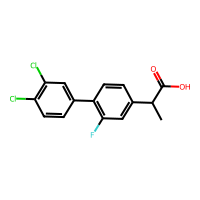
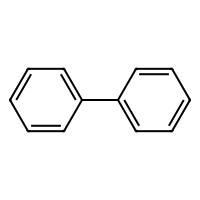
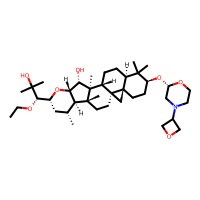
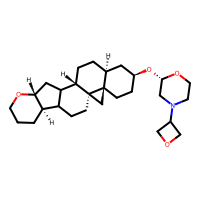
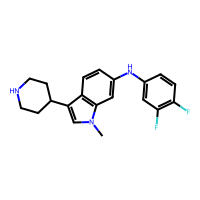
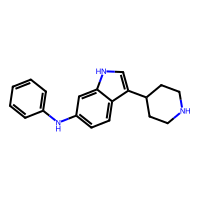
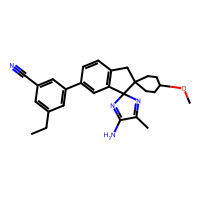
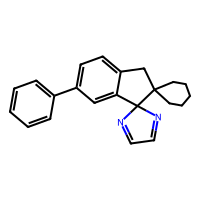
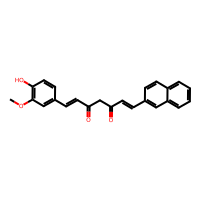
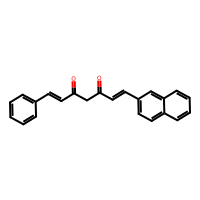

In [52]:
# Adding a new column with the Murcko SMILES of the molecules
PandasTools.AddMurckoToFrame(app_df_pubchem, "Molecules")

# Adding a column with the scaffolds in Mol type
PandasTools.AddMoleculeColumnToFrame(app_df_pubchem, smilesCol="Murcko_SMILES", molCol='Scaffold')

app_df_pubchem.sample(5)

🧪 El dataset cuenta con 602 scaffolds diferentes

🔶 Visualización de los 10 scaffolds más fecuentes en el dataset de Pubchem



[22:49:40] SMILES Parse Error: syntax error while parsing: Linear
[22:49:40] SMILES Parse Error: check for mistakes around position 1:
[22:49:40] Linear
[22:49:40] ^
[22:49:40] SMILES Parse Error: Failed parsing SMILES 'Linear' for input: 'Linear'


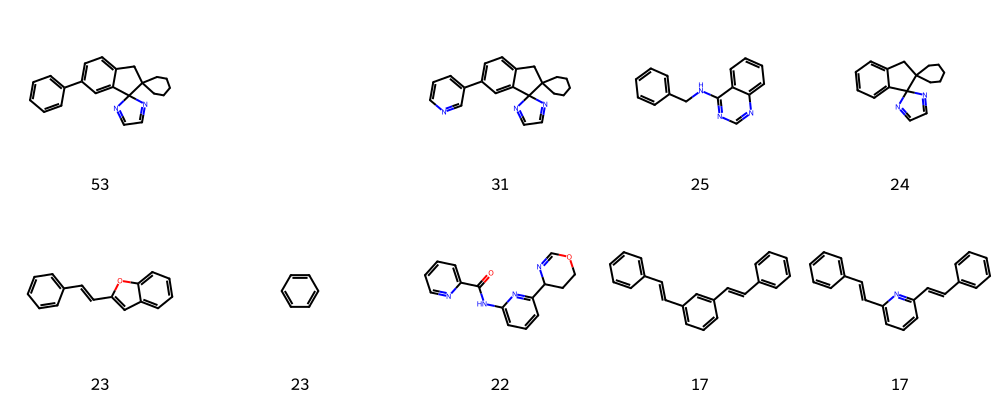

In [53]:
# Group data by scaffolds to count them (value_counts → reset_index)
pubchem_scaffolds = (app_df_pubchem['Murcko_SMILES'].value_counts().rename_axis('Murcko_SMILES').reset_index(name='Amount'))
print(f"🧪 El dataset cuenta con {pubchem_scaffolds.shape[0]} scaffolds diferentes\n")

# Identify and label the linear molecules
pubchem_scaffolds.at[1, 'Murcko_SMILES']='Linear molecule'

# Adding a column with the frequency of each scaffold in the dataset
pubchem_scaffolds['Frequency (%)'] = (pubchem_scaffolds['Amount'] / pubchem_scaffolds['Amount'].sum() * 100)

# Adding a column with the molecules of each scaffold
PandasTools.AddMoleculeColumnToFrame(pubchem_scaffolds, smilesCol='Murcko_SMILES')

# Vizualization of the most frequent scaffolds in the dataset
print(f"🔶 Visualización de los 10 scaffolds más fecuentes en el dataset de Pubchem\n")
PandasTools.FrameToGridImage(pubchem_scaffolds[0:10], column='ROMol', legendsCol='Amount', molsPerRow=5)

📗📘📙📌 **Obtención del dataset 2 y limpieza previa a la concatenación** 📌📙📘📗

In [54]:
# Searching the target in ChEMBL using the uniprot code P05067
target = search.target.filter(target_components__accession="P05067").only(['target_chembl_id', 'pref_name'])

# Converting the results to a DataFrame for better visualization
target_df = pd.DataFrame(target)
target_df

# Identifying the preferred name and ChEMBL ID of the target(s) with uniprot code P05067
app_pref_name = target[0]['pref_name']
app_chembl_id = target[0]['target_chembl_id']
print(f"🧪 El nombre preferido del target con código uniprot P05067 es {app_pref_name} y su ChEMBL ID es {app_chembl_id}")

🧪 El nombre preferido del target con código uniprot P05067 es Amyloid-beta precursor protein y su ChEMBL ID es CHEMBL2487


In [55]:
# Bioactivity (IC50) data retrieval for Amyloid-beta precursor protein (APP)
app_chembl = search.activity.filter(target_chembl_id=app_chembl_id, standard_type="IC50").only(['molecule_chembl_id', 'canonical_smiles', 'standard_value','standard_units'])

# Converting the results to a DataFrame for better visualization
app_df_chembl = pd.DataFrame(app_chembl)

# Duplicate removal (canonical smiles)
app_df_chembl = app_df_chembl.drop_duplicates(subset=['canonical_smiles'])

# Removal of molecules with missing bioactivity values
app_df_chembl= app_df_chembl.dropna(subset=['standard_value'])

# Converting the 'standard_value' column to numeric
app_df_chembl['standard_value'] = pd.to_numeric(app_df_chembl['standard_value'], errors='coerce')
app_df_chembl.sample(3)

,canonical_smiles,molecule_chembl_id,standard_units,standard_value,units,value
1065,CN(C)Cc1ccccc1Nc1cc(CNCCN2CCCCC2)cc(CNCCN2CCCC...,CHEMBL4226332,nM,10000.0,uM,10.0
1854,COC1CCC2(CC1)Oc1ccc(-c3cncc(Cl)c3)cc1C21N=C(C)...,CHEMBL3653698,nM,5.2,nM,5.2
194,COc1cc(/C=C/c2cccc(/C=C/c3ccc(N(C)C)c(OC)c3)n2...,CHEMBL391205,nM,800.0,uM,0.8


In [56]:
# Removing rows with missing SMILES values
app_df_chembl = app_df_chembl.dropna(subset=['canonical_smiles'])

# Adding a column with the 2d structures of the molecules
app_df_chembl['Molecules'] = app_df_chembl['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

# Calculation of descriptors of interest for the analysis
app_df_chembl["MW"] = app_df_chembl["Molecules"].apply(Descriptors.ExactMolWt)
app_df_chembl["HBA"] = app_df_chembl["Molecules"].apply(Descriptors.NumHAcceptors)
app_df_chembl["HBD"] = app_df_chembl["Molecules"].apply(Descriptors.NumHDonors)
app_df_chembl["logP"] = app_df_chembl["Molecules"].apply(Descriptors.MolLogP)
app_df_chembl["TPSA"] = app_df_chembl["Molecules"].apply(Descriptors.TPSA)
app_df_chembl["CSP3"] = app_df_chembl["Molecules"].apply(Descriptors.FractionCSP3)
app_df_chembl["NumRings"] = app_df_chembl["Molecules"].apply(Descriptors.RingCount)
app_df_chembl["HetAtoms"] = app_df_chembl["Molecules"].apply(Descriptors.NumHeteroatoms)
app_df_chembl["RotBonds"] = app_df_chembl["Molecules"].apply(Descriptors.NumRotatableBonds)

# Adding a new column with the Murcko SMILES of the molecules
PandasTools.AddMurckoToFrame(app_df_chembl, "Molecules")

# Adding a column with the scaffolds in Mol type
PandasTools.AddMoleculeColumnToFrame(app_df_chembl, smilesCol="Murcko_SMILES", molCol='Scaffold')

📗📘📙📌 **Revisión y concatenación entre los dataset 1 y 2** 📌📙📘📗

In [57]:
print(f"🔷 Las columnas del Dataset de PubChem son: {app_df_pubchem.columns.values}\n")
print(f"🔶 Las columnas del Dataset de ChEMBL son: {app_df_chembl.columns.values}")


🔷 Las columnas del Dataset de PubChem son: ['Pubchem_id' 'Activity Name' 'Activity Value [nM]' 'SMILES' 'Molecules'
 'MW' 'HBA' 'HBD' 'logP' 'TPSA' 'CSP3' 'NumRings' 'HetAtoms' 'RotBonds'
 'Murcko_SMILES' 'Scaffold']

🔶 Las columnas del Dataset de ChEMBL son: ['canonical_smiles' 'molecule_chembl_id' 'standard_units' 'standard_value'
 'units' 'value' 'Molecules' 'MW' 'HBA' 'HBD' 'logP' 'TPSA' 'CSP3'
 'NumRings' 'HetAtoms' 'RotBonds' 'Murcko_SMILES' 'Scaffold']


In [58]:
# Add "Source" column
app_df_chembl["Source"] = "ChEMBL"
app_df_pubchem["Source"] = "PubChem"

# Renaming columns for better merging
app_df_chembl.rename(columns={'molecule_chembl_id': 'Molecule_id', 'canonical_smiles': 'SMILES', 'standard_value': 'Activity Value [nM]'}, inplace=True)
app_df_pubchem.rename(columns={'Pubchem_id': 'Molecule_id'}, inplace=True)

# Dropping unnecessary columns from both datasets
columns_to_remove_chembl = ['standard_units', 'units', 'value']
columns_to_remove_pubchem = ['Activity Name']
app_df_chembl = app_df_chembl.drop(columns=columns_to_remove_chembl)
app_df_pubchem = app_df_pubchem.drop(columns=columns_to_remove_pubchem)

# Merging the datasets
app_df = pd.concat([app_df_pubchem, app_df_chembl], ignore_index=True)

# Canonization of the SMILES
app_df['SMILES'] = app_df['Molecules'].apply(lambda x: Chem.MolToSmiles(x) if x is not None else None)

# Drop duplicates based on SMILES
smiles_i = len(app_df)
app_df = app_df.drop_duplicates(subset=['SMILES'])
smiles_f = len(app_df)
print(f'🔷 Se encontraron y se eliminaron {smiles_i-smiles_f} compuestos duplicados en ambas bases de datos. Tamaño inicial: {smiles_i}, tamaño final: {smiles_f}.\n')
print(f"🔶 Las columnas del Dataset combinado son: {app_df.columns.values}")

🔷 Se encontraron y se eliminaron 1235 compuestos duplicados en ambas bases de datos. Tamaño inicial: 2880, tamaño final: 1645.

🔶 Las columnas del Dataset combinado son: ['Molecule_id' 'Activity Value [nM]' 'SMILES' 'Molecules' 'MW' 'HBA' 'HBD'
 'logP' 'TPSA' 'CSP3' 'NumRings' 'HetAtoms' 'RotBonds' 'Murcko_SMILES'
 'Scaffold' 'Source']


📗📘📙📌 **Creación de boxplot para el par de descriptores con menor correlación ('NumRings' y 'RotBonds')** 📌📙📘📗

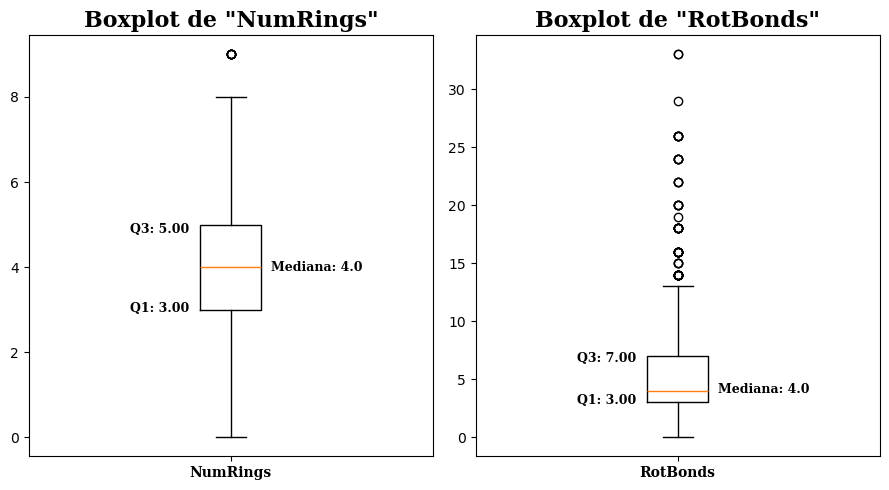

In [59]:
# General setting for the figure
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

# Data setting for the boxplot of the descriptor "NumRings"
axes[0].boxplot(app_df['NumRings'])

# Labels setting
axes[0].set_title('Boxplot de "NumRings"', fontsize=16, fontweight='bold', fontfamily='serif')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['NumRings'], fontweight='bold', fontfamily='serif')

# Annotations within the graph
axes[0].annotate(f'Mediana: {round(app_df.NumRings.median(), 1)}', xy=(1.1, 3.9), fontsize=9, fontweight='bold', fontfamily='serif')
axes[0].annotate(f'Q3: {app_df.NumRings.quantile(0.75):.2f}', xy=(0.75, 4.8), fontsize=9, fontweight='bold', fontfamily='serif')
axes[0].annotate(f'Q1: {app_df.NumRings.quantile(0.25):.2f}', xy=(0.75, 2.95), fontsize=9, fontweight='bold', fontfamily='serif')

# Data setting for the boxplot of the descriptor "RotBonds"
axes[1].boxplot(app_df['RotBonds'])

# Labels setting
axes[1].set_title('Boxplot de "RotBonds"', fontsize=16, fontweight='bold', fontfamily='serif')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['RotBonds'], fontweight='bold', fontfamily='serif')

# Annotations within the graph
axes[1].annotate(f'Mediana: {round(app_df.RotBonds.median(), 1)}', xy=(1.1, 3.8), fontsize=9, fontweight='bold', fontfamily='serif')
axes[1].annotate(f'Q3: {app_df.RotBonds.quantile(0.75):.2f}', xy=(0.75, 6.5), fontsize=9, fontweight='bold', fontfamily='serif')
axes[1].annotate(f'Q1: {app_df.RotBonds.quantile(0.25):.2f}', xy=(0.75, 2.9), fontsize=9, fontweight='bold', fontfamily='serif')

# Adjust spacing to avoid overlapping text
plt.tight_layout()
plt.show()

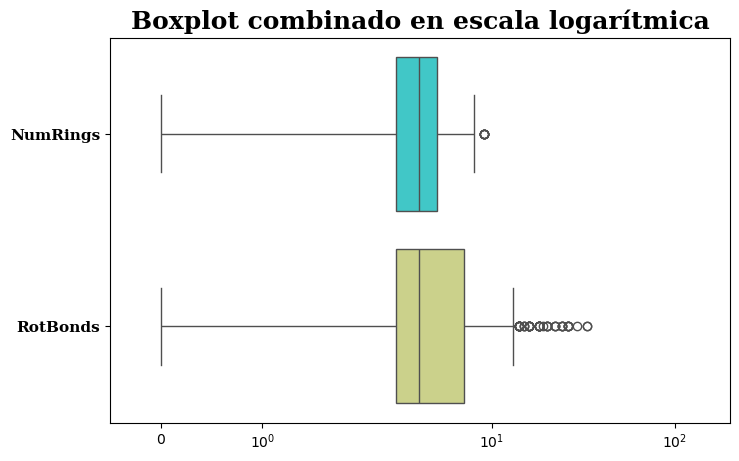

In [60]:
# Combined boxplot for NumRings and RotBonds (logarithmic scale)
plt.figure(figsize=(8,5))
box = sns.boxplot(data=app_df[["NumRings", "RotBonds"]], orient="h", palette="rainbow")

# Logarithmic scale for x-axis
box.set_xscale('symlog')

# Setting limits for better visualization of the data
box.axis(xmin=-0.5, xmax=200)

plt.title('Boxplot combinado en escala logarítmica', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.yticks(fontsize=11, fontweight='bold', fontfamily='serif')
plt.show()


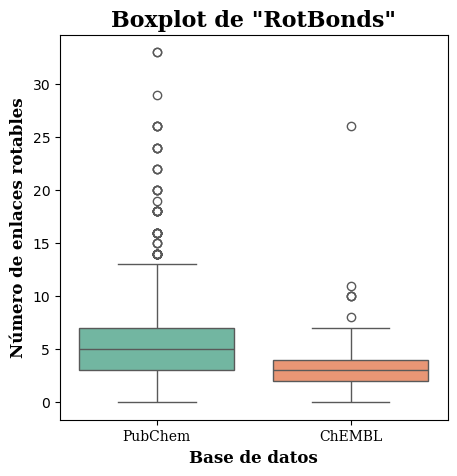

In [61]:
# Data setting for the boxplot of the descriptor "RotBonds"
plt.figure(figsize=(5, 5))
sns.boxplot(data=app_df, x='Source', y='RotBonds', hue='Source', palette="Set2", legend=False)

# Labels setting
plt.title('Boxplot de "RotBonds"', fontsize = 16, fontweight='bold', fontfamily='serif')
plt.xlabel('Base de datos', fontsize=12, fontweight='bold', fontfamily='serif')
plt.xticks(fontfamily='serif')
plt.ylabel('Número de enlaces rotables', fontsize=12, fontweight='bold', fontfamily='serif')

plt.show()

📌 Los compuestos de PubChem presentan, en general, un mayor número de enlaces rotables y una dispersión mucho más amplia en comparación con los de ChEMBL. Además, PubChem concentra una gran cantidad de valores atípicos extremos que alcanzan más de 30 enlaces, lo que indica la presencia de moléculas estructuralmente mucho más flexibles en esta base de datos.📌

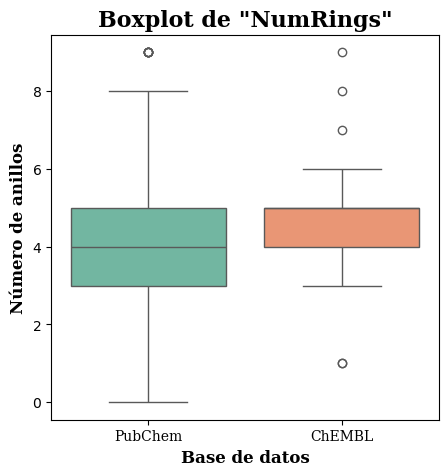

In [62]:
# Data setting for the boxplot of the descriptor "NumRings"
plt.figure(figsize=(5, 5))
sns.boxplot(data=app_df, x='Source', y='NumRings', hue='Source', palette="Set2", legend=False)

# Labels setting
plt.title('Boxplot de "NumRings"', fontsize = 16, fontweight='bold', fontfamily='serif')
plt.xlabel('Base de datos', fontsize=12, fontweight='bold', fontfamily='serif')
plt.xticks(fontfamily='serif')
plt.ylabel('Número de anillos', fontsize=12, fontweight='bold', fontfamily='serif')

plt.show()

📌 PubChem continene compuestos con más enlaces rotables y una dispersión mucho mayor (llena de valores atípicos extremos) frente a la distribución más compacta de ChEMBL. También, la cantidad de anillos es muy similar en ambas bases (media de 4), aunque PubChem presenta un rango de distribución un poco más amplio hacia valores menores (llegando a 0). 📌

📗📘📙📌 **Creación de boxplot para el SAscore (Synthetic Accessibility score)** 📌📙📘📗

,Molecule_id,Activity Value [nM],SMILES,Molecules,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds,Murcko_SMILES,Scaffold,Source,SAscore
881,162660161,3000.0,O=C(NO)c1ccc(Nc2c3ccccc3nc3ccccc23)cc1,,329.116427,4,3,4.25060,74.25,0.000000,4,5,3,c1ccc(Nc2c3ccccc3nc3ccccc23)cc1,,PubChem,1.914690
1258,134391603,4.1,COc1nc(-c2cc(C)c(N[C@@H](C)c3cc(F)cc(F)c3)nn2)...,,436.182316,7,1,4.80104,77.75,0.217391,4,9,6,c1ccc(CNc2ccc(-c3ccc(-n4ccnc4)cn3)nn2)cc1,,PubChem,3.346573
208,68552247,920.0,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)cc2OC)ccc1O,,368.125988,6,2,3.36990,93.06,0.142857,2,6,8,O=C(/C=C/c1ccccc1)CC(=O)/C=C/c1ccccc1,,PubChem,2.498399

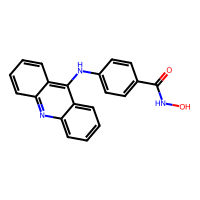
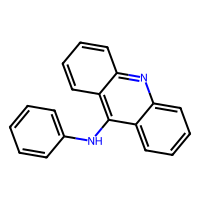
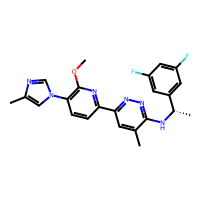
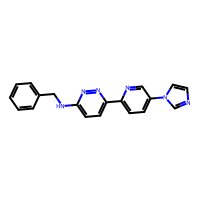
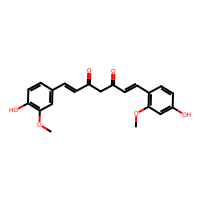
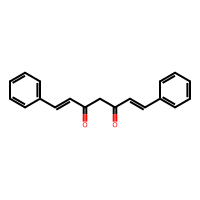

In [63]:
# Calculate SAscore
sascore_list = []
for mol in app_df['Molecules']:
    if mol is not None and isinstance(mol, Chem.Mol):
        SA = sascorer.calculateScore(mol)
    else:
        SA = None
    sascore_list.append(SA)

app_df['SAscore']=sascore_list
app_df.sample(3)

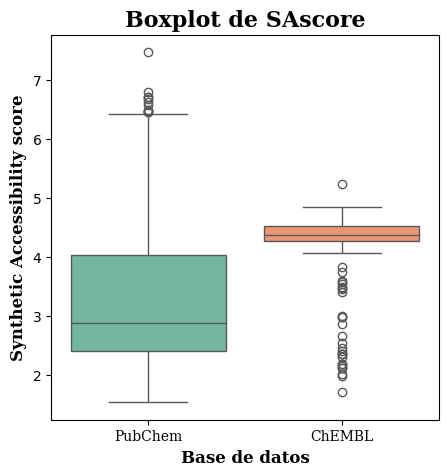

In [64]:
# Data setting for the boxplot of the SAscore
plt.figure(figsize=(5, 5))
sns.boxplot(data=app_df, x='Source', y='SAscore', hue='Source', palette="Set2", legend=False)

# Labels setting
plt.title('Boxplot de SAscore', fontsize = 16, fontweight='bold', fontfamily='serif')
plt.xlabel('Base de datos', fontsize=12, fontweight='bold', fontfamily='serif')
plt.xticks(fontfamily='serif')
plt.ylabel('Synthetic Accessibility score', fontsize=12, fontweight='bold', fontfamily='serif')

plt.show()

📗📘📙📌 **Recapitulación del proyecto y del dataset final** 📌📙📘📗

In [75]:
# Recap of the project and the final dataset

print(f"🧪 El dataset final contiene {len(app_df)} compuestos con información de bioactividad para la proteína APP provenientes de PubChem y ChEMBL.\n")
print(f"🧪 El dataset final incluye las siguientes columnas: {app_df.columns.values}\n")
print(f"🧪 El dataset final contine {len(app_df[app_df['Source'] == 'PubChem'])} moléculas provenientes de PubChem y {len(app_df[app_df['Source'] == 'ChEMBL'])} moléculas provenientes de ChEMBL.\n")
print(f"🧪 Los 5 compuestos con mayor actividad (menor valor de IC50) son: \n{app_df.nsmallest(5, 'Activity Value [nM]')[['Molecule_id', 'Activity Value [nM]', 'Source']]}\n")
print(f"🧪 El número de scaffolds diferentes en el dataset es: {app_df['Murcko_SMILES'].nunique()}\n")
print(f"🧪 El número promedio de anillos por molécula en cada base de datos es: \n{app_df.groupby('Source')['NumRings'].mean()}\n")
print(f"🧪 El número promedio de enlaces rotables por molécula en cada base de datos es: \n{app_df.groupby('Source')['RotBonds'].mean()}\n")
print(f"🧪 El SAscore promedio por molécula en cada base de datos es: \n{app_df.groupby('Source')['SAscore'].mean()}\n")

🧪 El dataset final contiene 1645 compuestos con información de bioactividad para la proteína APP provenientes de PubChem y ChEMBL.

🧪 El dataset final incluye las siguientes columnas: ['Molecule_id' 'Activity Value [nM]' 'SMILES' 'Molecules' 'MW' 'HBA' 'HBD'
 'logP' 'TPSA' 'CSP3' 'NumRings' 'HetAtoms' 'RotBonds' 'Murcko_SMILES'
 'Scaffold' 'Source' 'SAscore']

🧪 El dataset final contine 1475 moléculas provenientes de PubChem y 170 moléculas provenientes de ChEMBL.

🧪 Los 5 compuestos con mayor actividad (menor valor de IC50) son: 
    Molecule_id  Activity Value [nM]   Source
699    57404290                 0.10  PubChem
952    57385371                 0.26  PubChem
42     11354073                 0.30  PubChem
924    11577204                 0.50  PubChem
711    57387886                 0.56  PubChem

🧪 El número de scaffolds diferentes en el dataset es: 633

🧪 El número promedio de anillos por molécula en cada base de datos es: 
Source
ChEMBL     4.694118
PubChem    3.932203
Name: Nu